<a href="https://colab.research.google.com/github/ZukhrufianAbdullah/PCVK_Ganjil_2026/blob/main/Week-05/Week5_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Library
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

Mounted at /content/drive


<BarContainer object of 256 artists>

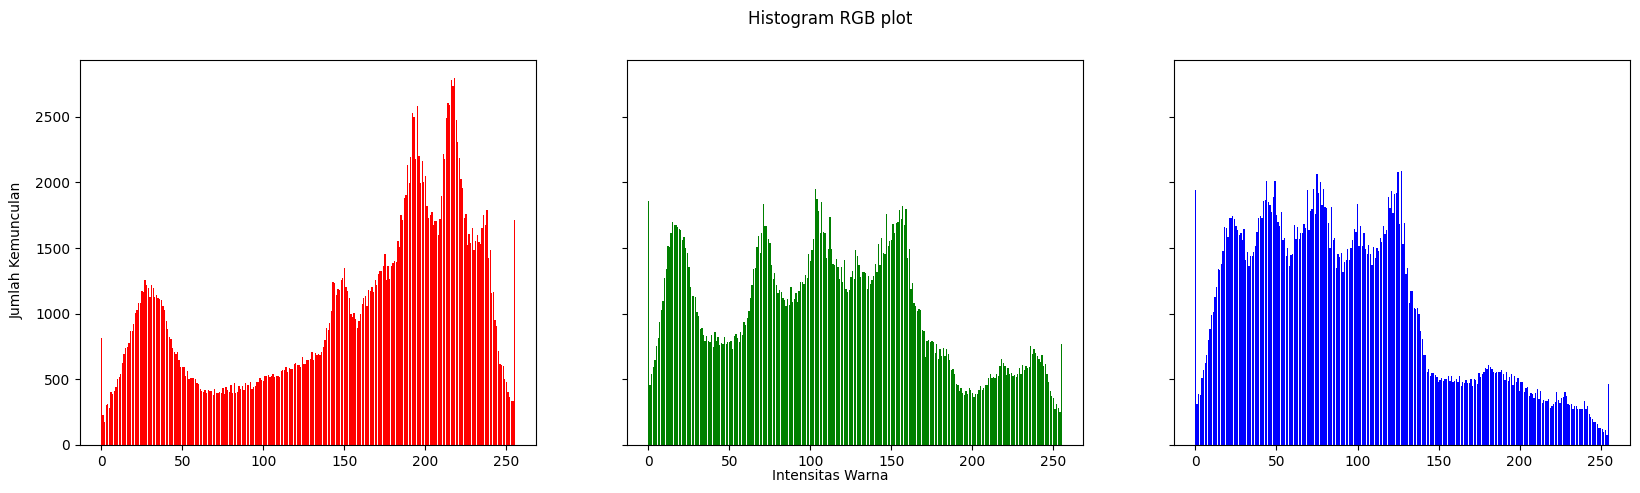

In [2]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lenna.jpeg') #Lenna
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

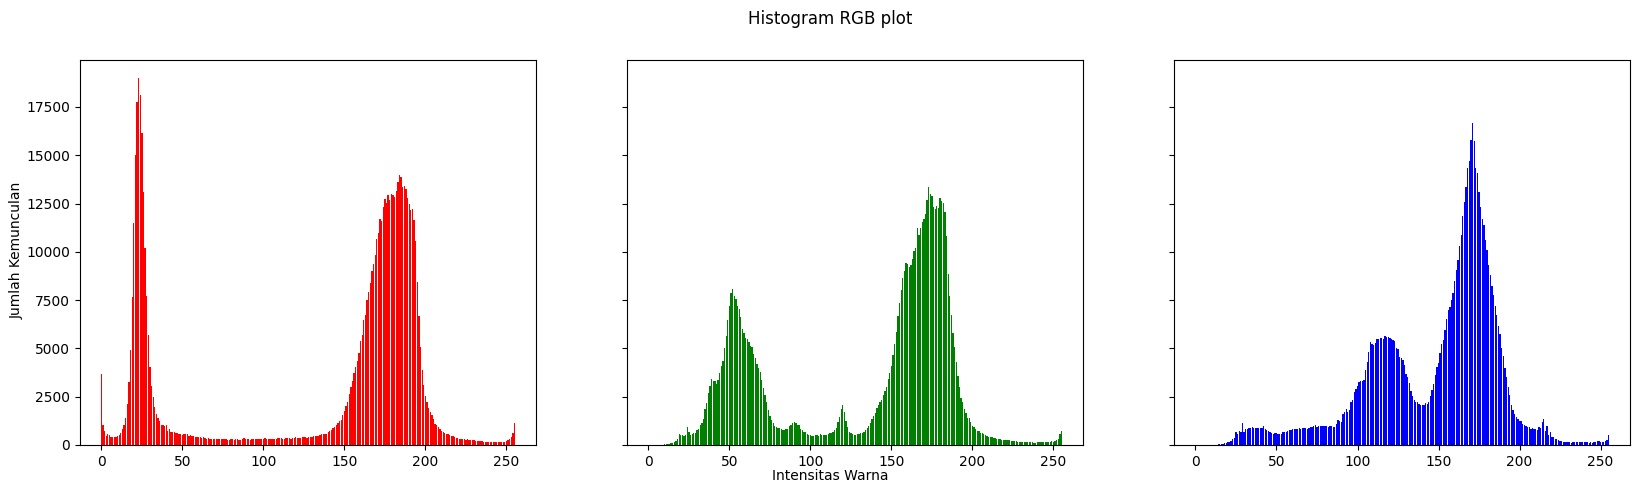

In [3]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/ktm_baru.jpeg') #KTM
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

# PERTANYAAN PRAKTIKUM E1
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [4]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Load image Lenna
img_lenna = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lenna.jpeg')
img_lenna_rgb = cv.cvtColor(img_lenna, cv.COLOR_BGR2RGB)

# --- 1a. Metode Manual ---
height, width, depth = img_lenna_rgb.shape
manual_red = [0]*256
manual_green = [0]*256
manual_blue = [0]*256

for y in range(height):
    for x in range(width):
        manual_red[img_lenna_rgb[y, x, 0]] += 1
        manual_green[img_lenna_rgb[y, x, 1]] += 1
        manual_blue[img_lenna_rgb[y, x, 2]] += 1

manual_hist = np.array([manual_red, manual_green, manual_blue], dtype=np.float32)

# --- 1b. Metode NumPy (np.histogram) ---
numpy_red, _ = np.histogram(img_lenna_rgb[:,:,0], bins=256, range=(0,256))
numpy_green, _ = np.histogram(img_lenna_rgb[:,:,1], bins=256, range=(0,256))
numpy_blue, _ = np.histogram(img_lenna_rgb[:,:,2], bins=256, range=(0,256))

numpy_hist = np.array([numpy_red, numpy_green, numpy_blue], dtype=np.float32)

# --- 1c. Metode OpenCV (cv.calcHist) ---
# Catatan: cv.calcHist menerima list image dan index channel
opencv_red = cv.calcHist([img_lenna_rgb], [0], None, [256], [0, 256]).flatten()
opencv_green = cv.calcHist([img_lenna_rgb], [1], None, [256], [0, 256]).flatten()
opencv_blue = cv.calcHist([img_lenna_rgb], [2], None, [256], [0, 256]).flatten()

opencv_hist = np.array([opencv_red, opencv_green, opencv_blue], dtype=np.float32)

# --- 1d. Perbandingan Selisih Maksimum ---
diff_manual_numpy = np.max(np.abs(manual_hist - numpy_hist))
diff_manual_opencv = np.max(np.abs(manual_hist - opencv_hist))
diff_numpy_opencv = np.max(np.abs(numpy_hist - opencv_hist))

print("=== PEMBUKTIAN SELISIH PADA LENNA.JPEG ===")
print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_numpy}")
print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_opencv}")
print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_numpy_opencv}")

=== PEMBUKTIAN SELISIH PADA LENNA.JPEG ===
Selisih Maksimum (Manual vs NumPy) : 0.0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0


In [5]:
import numpy as np
import cv2 as cv
import os

# Path direktori gambar KTM
ktm_path = '/content/drive/MyDrive/PCVK/Gambar/KTM1b.jpeg'

print(f"Menggunakan file: {ktm_path}")
img_ktm = cv.imread(ktm_path)
if img_ktm is None:
    raise FileNotFoundError(f"File {ktm_path} tidak ditemukan. Harap pastikan lokasi dan namanya sudah benar.")
img_ktm_rgb = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

# --- Manual ---
h_ktm, w_ktm, _ = img_ktm_rgb.shape
man_r, man_g, man_b = [0]*256, [0]*256, [0]*256
for y in range(h_ktm):
    for x in range(w_ktm):
        man_r[img_ktm_rgb[y, x, 0]] += 1
        man_g[img_ktm_rgb[y, x, 1]] += 1
        man_b[img_ktm_rgb[y, x, 2]] += 1
man_hist = np.array([man_r, man_g, man_b], dtype=np.float32)

# --- NumPy ---
np_r, _ = np.histogram(img_ktm_rgb[:,:,0], bins=256, range=(0,256))
np_g, _ = np.histogram(img_ktm_rgb[:,:,1], bins=256, range=(0,256))
np_b, _ = np.histogram(img_ktm_rgb[:,:,2], bins=256, range=(0,256))
np_hist = np.array([np_r, np_g, np_b], dtype=np.float32)

# --- OpenCV ---
cv_r = cv.calcHist([img_ktm_rgb], [0], None, [256], [0, 256]).flatten()
cv_g = cv.calcHist([img_ktm_rgb], [1], None, [256], [0, 256]).flatten()
cv_b = cv.calcHist([img_ktm_rgb], [2], None, [256], [0, 256]).flatten()
cv_hist = np.array([cv_r, cv_g, cv_b], dtype=np.float32)

# --- Perbandingan Selisih ---
diff_man_np = np.max(np.abs(man_hist - np_hist))
diff_man_cv = np.max(np.abs(man_hist - cv_hist))
diff_np_cv = np.max(np.abs(np_hist - cv_hist))

print("=== PEMBUKTIAN SELISIH HISTOGRAM PADA KTM1b.jpeg ===")
print(f"Selisih Maksimum (Manual vs NumPy) : {diff_man_np}")
print(f"Selisih Maksimum (Manual vs OpenCV): {diff_man_cv}")
print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_np_cv}")

Menggunakan file: /content/drive/MyDrive/PCVK/Gambar/KTM1b.jpeg
=== PEMBUKTIAN SELISIH HISTOGRAM PADA KTM1b.jpeg ===
Selisih Maksimum (Manual vs NumPy) : 0.0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

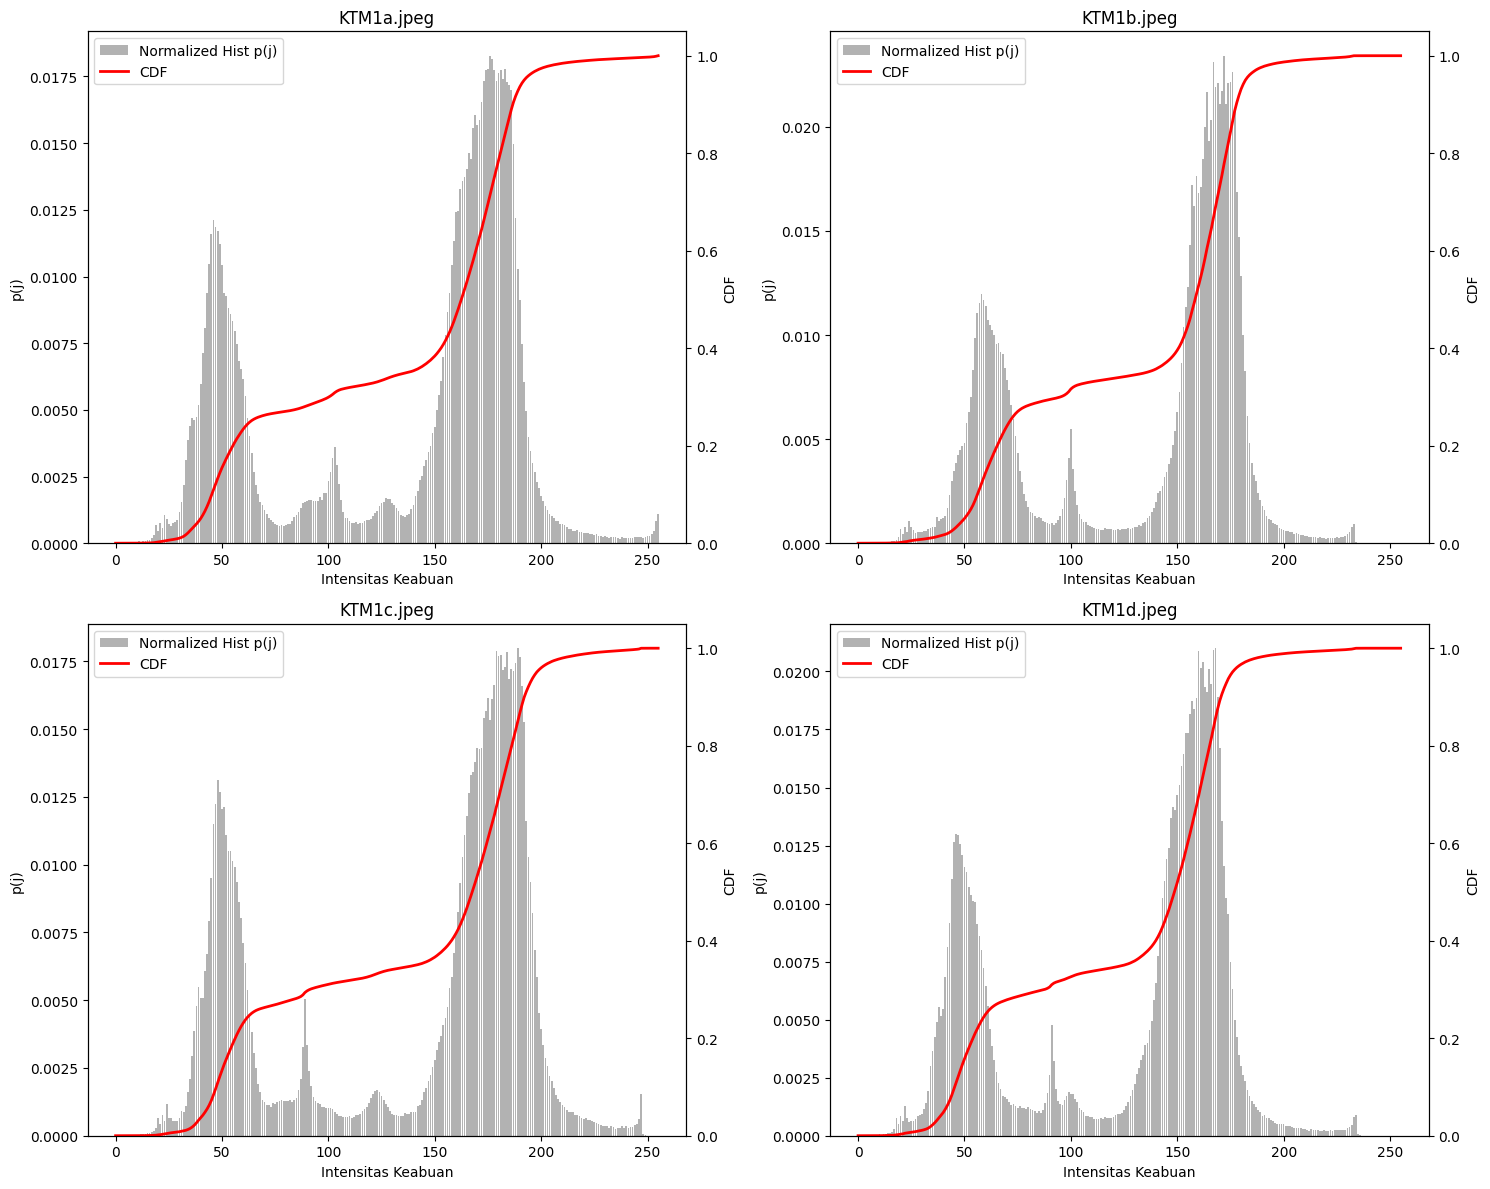

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = '/content/drive/MyDrive/PCVK/Gambar/'
ktm_files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.ravel()

for i, file_name in enumerate(ktm_files):
    img_path = os.path.join(base_path, file_name)
    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Gambar {file_name} tidak ditemukan di: {img_path}")

    # 1. Hitung histogram
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])

    # 2. Normalisasi Histogram p(j) = hist / total_pixel
    pdf = hist / img.size

    # 3. Hitung CDF
    cdf = pdf.cumsum()

    # Plotting PDF
    ax = axs[i]
    ax.bar(range(256), pdf, color='gray', alpha=0.6, label='Normalized Hist p(j)')

    # Sumbu Y sekunder untuk CDF
    ax_cdf = ax.twinx()
    ax_cdf.plot(range(256), cdf, color='red', linewidth=2, label='CDF')
    ax_cdf.set_ylim(0, 1.05)

    ax.set_title(file_name)
    ax.set_xlabel('Intensitas Keabuan')
    ax.set_ylabel('p(j)')
    ax_cdf.set_ylabel('CDF')

    # Gabungkan legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_cdf.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Penjelasan:
Perbedaan bentuk kurva CDF antara citra paling gelap (KTM1a) dan citra paling terang (KTM1d) terlihat pada tingkat kelajuannya dalam mencapai nilai akumulasi 1.0; kurva CDF citra paling gelap melonjak sangat curam sejak area intensitas rendah karena sebagian besar piksel terkonsentrasi di area gelap akibat kondisi akuisisi yang kurang cahaya (underexposure), sedangkan kurva CDF citra paling terang berbentuk sangat landai di awal dan baru melonjak curam di area intensitas tinggi karena pikselnya didominasi oleh warna terang akibat paparan pencahayaan yang berlebih (overexposure).

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

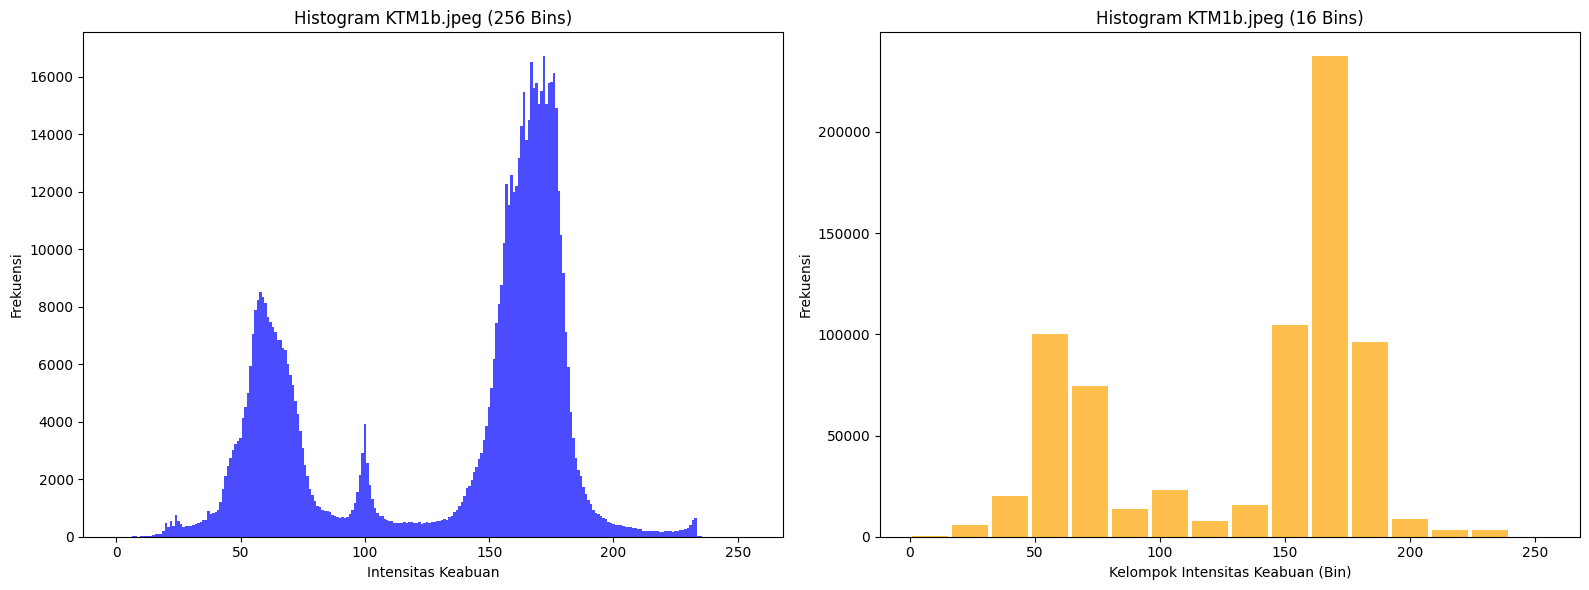

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

ktm_path = '/content/drive/MyDrive/PCVK/Gambar/KTM1b.jpeg'
img_ktm = cv.imread(ktm_path, cv.IMREAD_GRAYSCALE)

if img_ktm is None:
    raise FileNotFoundError(f"Gambar KTM1b.jpeg tidak ditemukan di: {ktm_path}")

# Definisikan parameter bins yang dikurangi (misalkan PARAM['bins'] = 16)
reduced_bins = 16

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram 256 Bins
hist_256, bins_256 = np.histogram(img_ktm.flatten(), bins=256, range=[0, 256])
axs[0].bar(range(256), hist_256, color='blue', alpha=0.7, width=1.0)
axs[0].set_title('Histogram KTM1b.jpeg (256 Bins)')
axs[0].set_xlabel('Intensitas Keabuan')
axs[0].set_ylabel('Frekuensi')

# Plot 2: Histogram dengan Jumlah Bins Dikurangi (Reduced Bins)
hist_reduced, bins_reduced = np.histogram(img_ktm.flatten(), bins=reduced_bins, range=[0, 256])
bin_width = 256 / reduced_bins
bin_centers = np.arange(reduced_bins) * bin_width + (bin_width / 2)
axs[1].bar(bin_centers, hist_reduced, color='orange', alpha=0.7, width=bin_width * 0.9)
axs[1].set_title(f'Histogram KTM1b.jpeg ({reduced_bins} Bins)')
axs[1].set_xlabel('Kelompok Intensitas Keabuan (Bin)')
axs[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Penjelasan:
Ketika jumlah bin dikurangi (misalnya dari 256 menjadi 16 bin), informasi yang hilang adalah detail variasi tingkat keabuan halus (fine-grained intensity details) pada citra, karena beberapa nilai intensitas piksel yang bertetangga dipaksa untuk dikelompokkan ke dalam satu batas kelas yang sama sehingga fluktuasi perbedaan warna yang tipis menjadi tidak terdeteksi dan menyebabkan kontras mikro pada gambar menghilang.

# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

In [13]:
NIM = "244107020236"

def histogram_manual(channel):
    """Menghitung histogram manual untuk satu kanal 2D."""
    h = np.zeros(256, dtype=np.int32)
    for val in channel.flat:
        h[val] += 1
    return h

def equalize_manual_channel(channel):
    """Histogram equalization manual untuk 1 kanal, rumus Ko = round(CDF * (L-1))."""
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    L = 256
    tabel_transformasi = np.round(cdf * (L - 1)).astype(np.uint8)
    return tabel_transformasi[channel]

def equalize_manual_bgr(bgr):
    """Terapkan equalize_manual_channel ke tiap kanal B, G, R lalu digabung."""
    b, g, r = cv.split(bgr)
    return cv.merge([equalize_manual_channel(b),
                      equalize_manual_channel(g),
                      equalize_manual_channel(r)])

def proses_equalization(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    hasil = equalize_manual_bgr(bgr)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));   axs[0].set_title('Sebelum'); axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB)); axs[1].set_title('Sesudah'); axs[1].axis('off')
    fig.suptitle(NIM + ' - ' + nama_file)
    plt.show()

    warna = ['Biru', 'Hijau', 'Merah']
    matplotlib_colors = {'Biru': 'blue', 'Hijau': 'green', 'Merah': 'red'}
    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    for i, w in enumerate(warna):
        axs[0, i].bar(range(256), histogram_manual(cv.split(bgr)[i]), color=matplotlib_colors[w])
        axs[0, i].set_title('Sebelum - ' + w)
        axs[1, i].bar(range(256), histogram_manual(cv.split(hasil)[i]), color=matplotlib_colors[w])
        axs[1, i].set_title('Sesudah - ' + w)
    fig.suptitle('Histogram RGB plot')
    plt.tight_layout()
    plt.show()
    return bgr, hasil

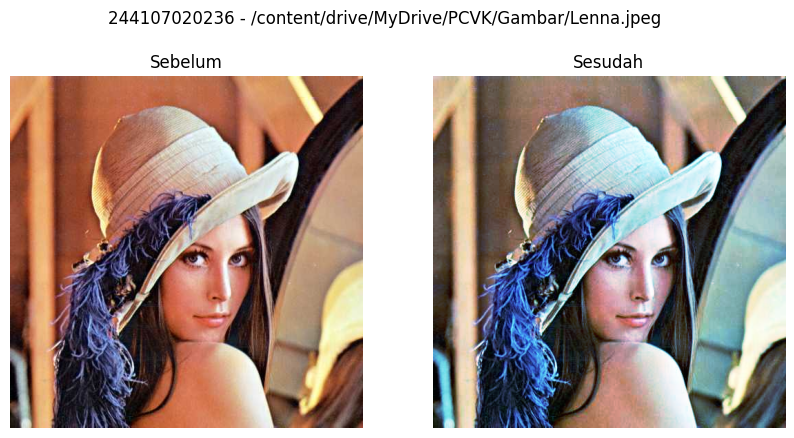

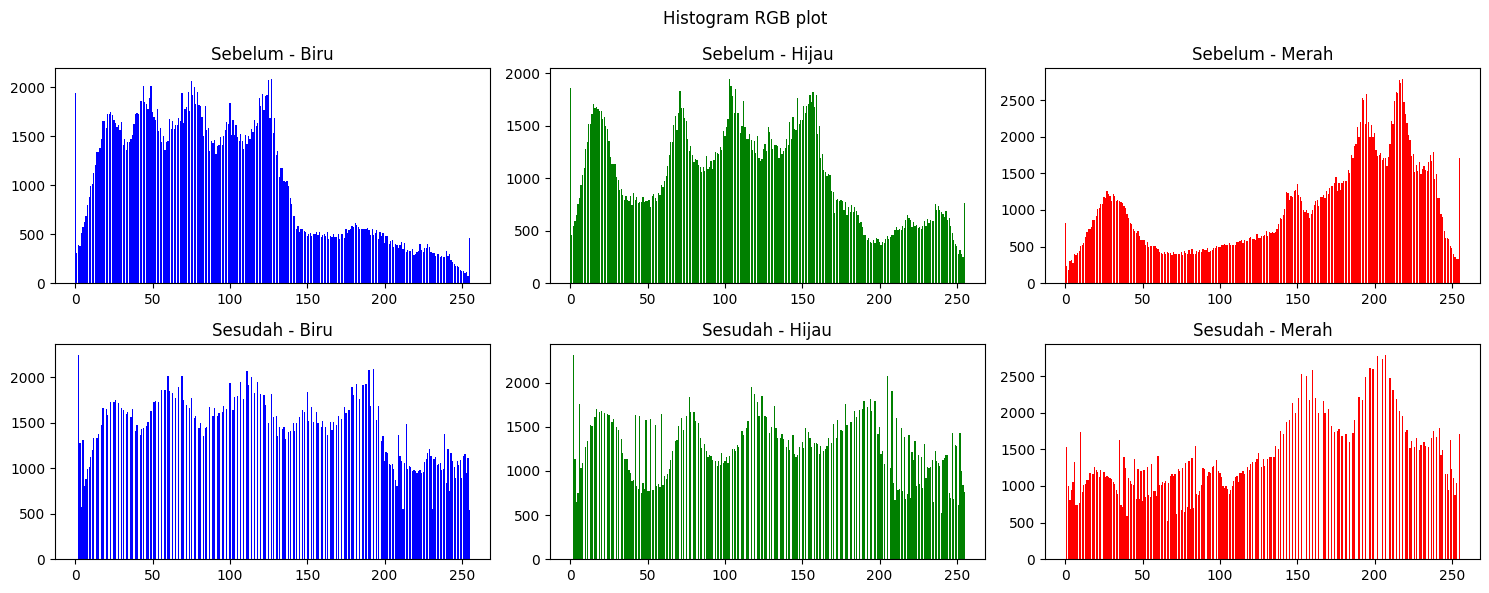

In [17]:
# Tahap 1: citra contoh
PATH = '/content/drive/MyDrive/PCVK/Gambar'
_ = proses_equalization(PATH + '/Lenna.jpeg', PATH + '/Lenna.jpeg')

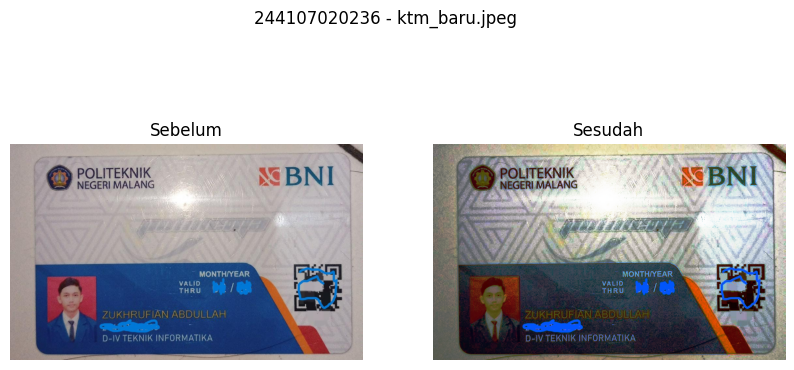

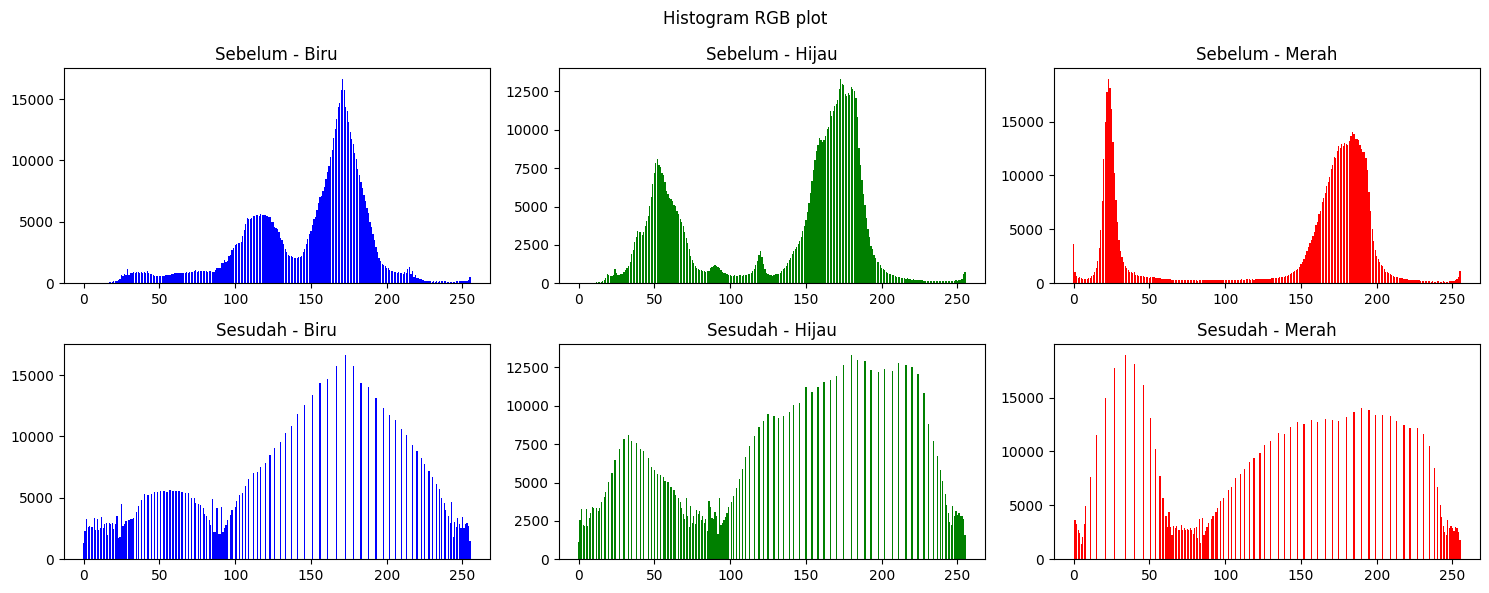

In [18]:
# Tahap 2: citra KTM milik sendiri
bgr_ktm1a, hasil_manual_ktm1a = proses_equalization(PATH + '/ktm_baru.jpeg', 'ktm_baru.jpeg')

In [19]:
# Bandingkan hasil equalizeHist dengan hasil implementasi manual Anda dengan menghitung selisih maksimum antara keduanya, baik pada lena_lc.jpg maupun pada KTM1a.
def bandingkan_equalize(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    hasil_manual = equalize_manual_bgr(bgr)

    b, g, r = cv.split(bgr)
    hasil_cv = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])

    selisih = np.max(np.abs(hasil_manual.astype(int) - hasil_cv.astype(int)))
    print(f'{nama_file}: selisih maksimum manual vs cv.equalizeHist (semua kanal) = {selisih}')

bandingkan_equalize(PATH + '/Lenna.jpeg', 'Lenna.jpeg')
bandingkan_equalize(PATH + '/ktm_baru.jpeg', 'ktm_baru.jpeg')

Lenna.jpeg: selisih maksimum manual vs cv.equalizeHist (semua kanal) = 2
ktm_baru.jpeg: selisih maksimum manual vs cv.equalizeHist (semua kanal) = 2


Penyebab selisih maksimum tidak nol (bernilai 2) antara implementasi manual dan cv.equalizeHist disebabkan oleh dua faktor teknis berikut:

1. Perbedaan Skema Pembulatan (Rounding): Implementasi manual Anda menggunakan fungsi np.round() (pembulatan ke nilai terdekat tergenap atau round half to even), sedangkan OpenCV menggunakan pembulatan standar tipe integer bawaan atau metode pemetaan yang sedikit berbeda ketika membagi skala histogram.
2. Skala Intensitas yang Digunakan: Pada kode manual, normalisasi dan pemetaan ulang menggunakan rumus akumulasi CDF yang dikalikan dengan $L-1$$L-1$ ($255$$255$), sedangkan pembagi pembulatan internal OpenCV memiliki optimasi aritmatika integer tertentu yang dapat menghasilkan perbedaan sensitivitas sebesar $\pm 1$$\pm 1$ hingga $2$$2$ angka keabuan di tingkat batas transisi intensitas.

In [20]:
# Ekualisasi
def equalisasi_warna(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)

    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.suptitle(nama_file)
    plt.show()

    return bgr, judul, citra

def geser_hue(asli, hasil):
    """Rata-rata pergeseran Hue (Hue melingkar 0-179 di OpenCV)."""
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

def cetak_tabel_hue(bgr, judul, citra):
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (
            t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

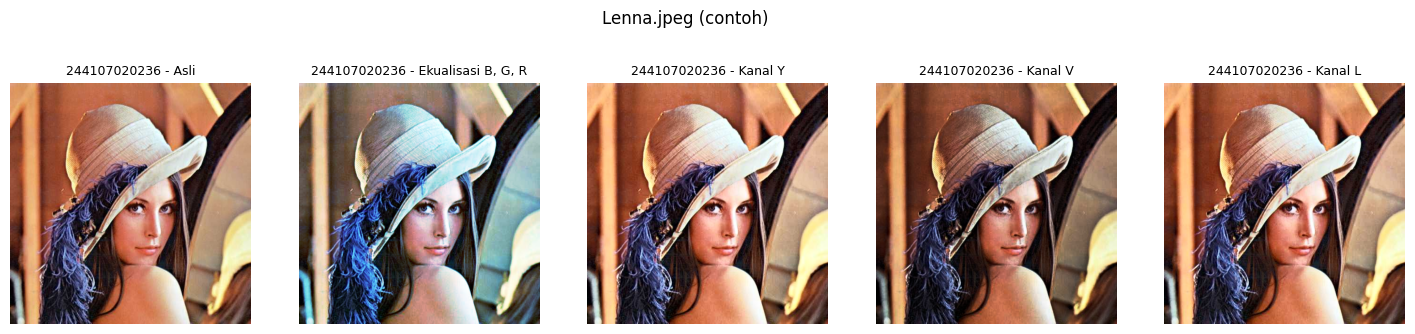

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


In [21]:
# Tahap 1: citra contoh
bgr, judul, citra = equalisasi_warna(PATH + '/Lenna.jpeg', 'Lenna.jpeg (contoh)')
cetak_tabel_hue(bgr, judul, citra)

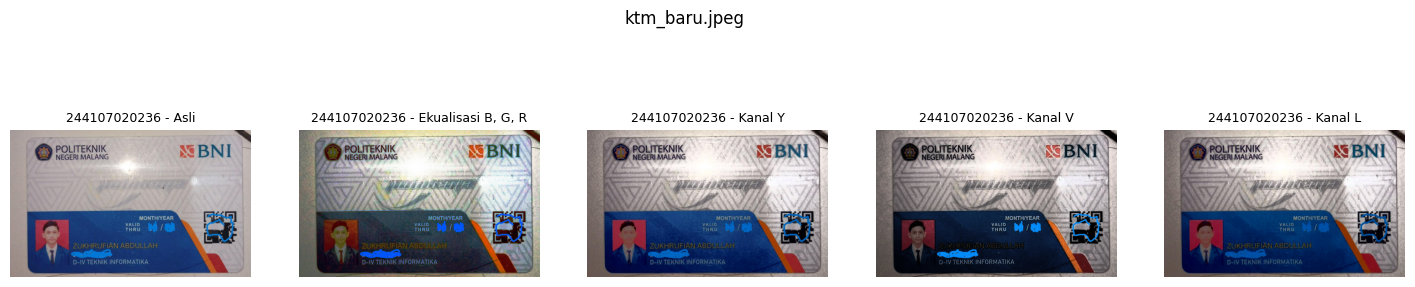

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            135.5
Ekualisasi B, G, R                58.14            128.8
Kanal Y                            0.62            129.2
Kanal V                            2.10            115.5
Kanal L                            3.71            122.8


In [22]:
# Tahap 2: citra KTM milik sendiri
bgr_ktm, judul_ktm, citra_ktm = equalisasi_warna(PATH + '/ktm_baru.jpeg', 'ktm_baru.jpeg')
cetak_tabel_hue(bgr_ktm, judul_ktm, citra_ktm)


# Pertanyaan Analisis Ekualisasi Warna

**1. Pergeseran Hue Paling Besar:**
Berdasarkan data tabel hasil citra KTM Anda (`ktm_baru.jpeg`), metode **Ekualisasi B, G, R** menghasilkan pergeseran Hue paling besar dengan nilai mencapai **58.14 derajat**. Hal ini terjadi karena ekualisasi dilakukan secara independen pada setiap kanal warna, merusak rasio proporsi warna asli dan menyebabkan pergeseran warna (*color cast*) yang sangat drastis.

**2. Alasan Pergeseran Hue Tidak Persis Nol pada Kanal Terang (Y, V, L):**
Ekualisasi pada ruang warna terang (seperti Y pada YCrCb, V pada HSV, atau L pada LAB) idealnya hanya mengubah kecerahan tanpa menyentuh komponen warna (Hue/Krominan). Namun, pergeseran Hue tetap bernilai tidak nol (misalnya 0.62° pada Y, 2.10° pada V, dan 3.71° pada L) karena ketika citra dikonversi kembali ke ruang warna **BGR**, terjadi operasi matematika matematika berupa pembulatan (*rounding*) bilangan desimal ke integer (`uint8`) serta pemotongan nilai (*clipping*) jika hasil perhitungan berada di luar rentang `[0, 255]`. Hal ini mengubah sedikit rasio nilai asli B, G, dan R sehingga mengubah nilai Hue-nya secara mikro.

**3. Kanal yang Paling Sesuai untuk Foto KTM Anda:**
Berdasarkan angka kecerahan dan pergeseran Hue:
* **Kanal Y (YCrCb)** adalah yang paling sesuai. Kanal Y memberikan rata-rata terang yang sangat baik (**129.2**) dengan nilai pergeseran Hue yang paling minim (**0.62 derajat**).
* **Dasar Penilaian:** Pada visualisasi citra KTM Anda, hasil **Kanal Y** terlihat paling natural dan informatif karena bagian teks pada kartu KTM serta foto wajah tetap memiliki kontras yang tajam tanpa mengalami kejenuhan warna atau pemutihan berlebih (*over-saturation*) seperti yang terlihat pada hasil ekualisasi BGR langsung.


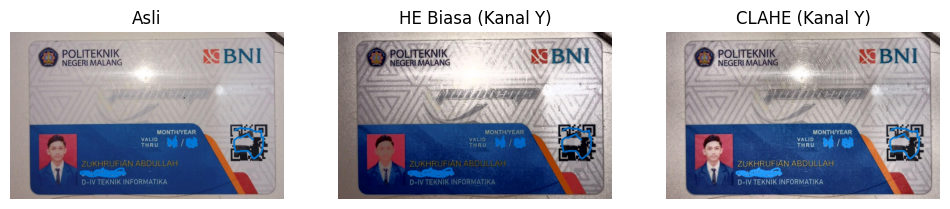

Metode                         Geser Hue (der)        Rerata Terang
HE Biasa (Kanal Y)                        0.62                129.2
CLAHE (Kanal Y)                           0.02                136.5


In [23]:
# 4. Implementasi CLAHE untuk dibandingkan dengan Ekualisasi biasa
PARAM = {
    'clip': 2.0,
    'tile': 8
}

def bandingkan_clahe_vs_he(path_gambar):
    bgr = cv.imread(path_gambar)

    # Ekualisasi Biasa pada Kanal Y (YCrCb)
    ycrcb_he = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y_he, cr_he, cb_he = cv.split(ycrcb_he)
    hasil_he = cv.cvtColor(cv.merge([cv.equalizeHist(y_he), cr_he, cb_he]), cv.COLOR_YCrCb2BGR)

    # CLAHE pada Kanal Y (YCrCb)
    ycrcb_clahe = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y_clahe, cr_clahe, cb_clahe = cv.split(ycrcb_clahe)

    clahe_obj = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    y_clahe_applied = clahe_obj.apply(y_clahe)
    hasil_clahe = cv.cvtColor(cv.merge([y_clahe_applied, cr_clahe, cb_clahe]), cv.COLOR_YCrCb2BGR)

    # Visualisasi perbandingan
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    plt.title('Asli')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv.cvtColor(hasil_he, cv.COLOR_BGR2RGB))
    plt.title('HE Biasa (Kanal Y)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv.cvtColor(hasil_clahe, cv.COLOR_BGR2RGB))
    plt.title('CLAHE (Kanal Y)')
    plt.axis('off')
    plt.show()

    # Cetak Tabel Perbandingan
    print('%-25s %20s %20s' % ('Metode', 'Geser Hue (der)', 'Rerata Terang'))
    print('%-25s %20.2f %20.1f' % ('HE Biasa (Kanal Y)', geser_hue(bgr, hasil_he) * 2, cv.cvtColor(hasil_he, cv.COLOR_BGR2GRAY).mean()))
    print('%-25s %20.2f %20.1f' % ('CLAHE (Kanal Y)', geser_hue(bgr, hasil_clahe) * 2, cv.cvtColor(hasil_clahe, cv.COLOR_BGR2GRAY).mean()))

_ = bandingkan_clahe_vs_he(PATH + '/ktm_baru.jpeg')

# PERTANYAAN PRAKTIKUM E2
1. Ekualisasi global pada citra KTM Anda
    * Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.
    * Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
    * Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

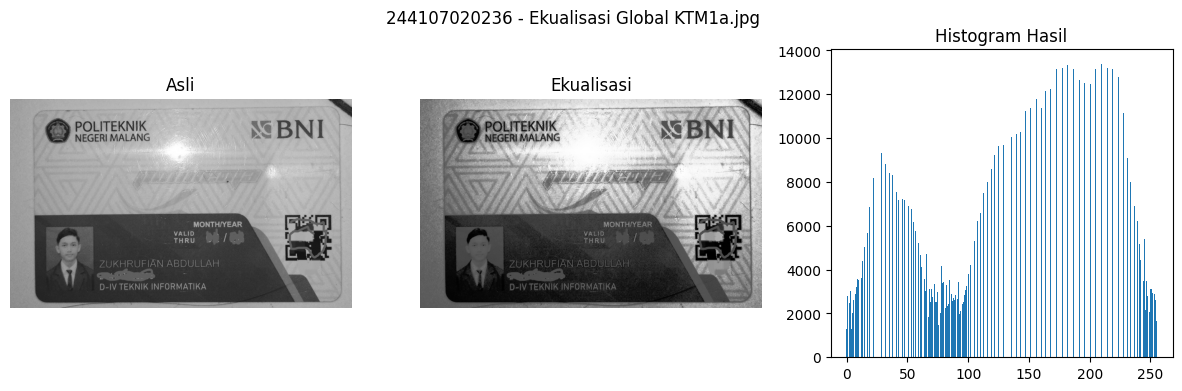

PSNR asli vs hasil ekualisasi manual: 18.6 dB
PSNR asli vs hasil ekualisasi cv: 18.6 dB


In [26]:
def hitung_psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255.0 ** 2) / mse)

gray_a = cv.imread(PATH + '/ktm_baru.jpeg', cv.IMREAD_GRAYSCALE)
hasil_manual_a = equalize_manual_channel(gray_a)
hasil_cv_a = cv.equalizeHist(gray_a)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(gray_a, cmap='gray');        axs[0].set_title('Asli');       axs[0].axis('off')
axs[1].imshow(hasil_cv_a, cmap='gray');    axs[1].set_title('Ekualisasi'); axs[1].axis('off')
axs[2].bar(range(256), histogram_manual(hasil_cv_a))
axs[2].set_title('Histogram Hasil')
fig.suptitle(NIM + ' - Ekualisasi Global KTM1a.jpg')
plt.show()

psnr_manual = hitung_psnr(gray_a, hasil_manual_a)
psnr_cv = hitung_psnr(gray_a, hasil_cv_a)
print('PSNR asli vs hasil ekualisasi manual:', round(psnr_manual, 2), 'dB')
print('PSNR asli vs hasil ekualisasi cv:', round(psnr_cv, 2), 'dB')

* Mengapa PSNR Turun: PSNR mengukur kemiripan matematis piksel-per-piksel dengan citra asli. Ekualisasi histogram secara sengaja mengubah intensitas piksel secara drastis untuk menaikkan kontras. Hal ini memperbesar selisih matematis (MSE) sehingga nilai PSNR otomatis jatuh, meskipun citra terlihat lebih jelas di mata manusia.

* Kelayakan PSNR untuk Keterbacaan: Tidak layak. PSNR adalah metrik untuk mengukur rekonstruksi (kemiripan/reproduksi objek asli) bukan kualitas visual keterbacaan (readability). Citra dengan PSNR rendah justru sering kali jauh lebih mudah dibaca dibanding citra aslinya yang buram.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda
    * Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
    * Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

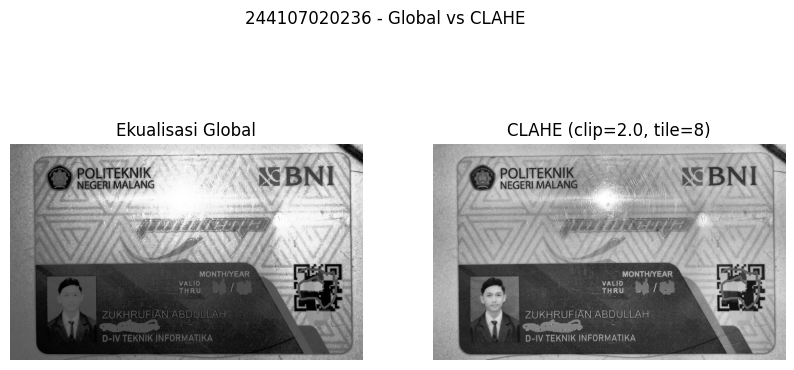

In [27]:
clahe_default = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_a = clahe_default.apply(gray_a)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(hasil_cv_a, cmap='gray');    axs[0].set_title('Ekualisasi Global'); axs[0].axis('off')
axs[1].imshow(hasil_clahe_a, cmap='gray'); axs[1].set_title(f"CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})"); axs[1].axis('off')
fig.suptitle(NIM + ' - Global vs CLAHE')
plt.show()

NIM dan nama pada CLAHE lebih mudah terbaca

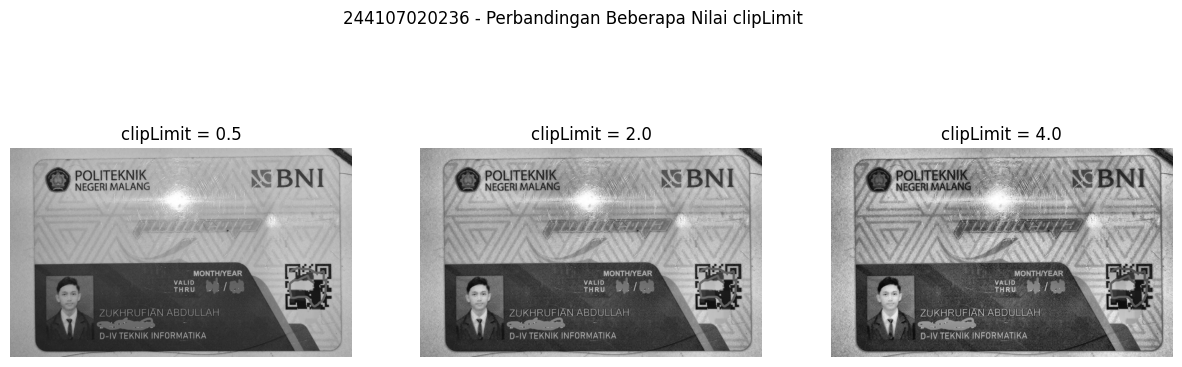

In [28]:
nilai_clip_lain = [0.5, 2.0, 4.0]

fig, axs = plt.subplots(1, len(nilai_clip_lain), figsize=(15, 5))
for i, clip in enumerate(nilai_clip_lain):
    clahe_coba = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe_coba.apply(gray_a)
    axs[i].imshow(hasil, cmap='gray')
    axs[i].set_title(f'clipLimit = {clip}')
    axs[i].axis('off')
fig.suptitle(NIM + ' - Perbandingan Beberapa Nilai clipLimit')
plt.show()

* clipLimit Terbaik: clipLimit = 2.0, karena menghasilkan ketajaman teks yang pas dan seimbang tanpa memperkuat noise secara berlebih.
* Lokasi Noise Menonjol: Pada clipLimit = 4.0, noise (bintik-bintik kasar/grain) mulai terlihat menonjol pada area latar belakang kartu yang polos dan pada pasfoto wajah.

# E-3 TUGAS PRAKTIKUM DITHERING

In [29]:
# dithering Floyd-Steinberg
def floyd_steinberg(channel, L=2):
    """Dithering error-diffusion Floyd-Steinberg untuk 1 kanal (sesuai rumus modul)."""
    img = channel.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y, x + 1]     += error * 7 / 16
            if x > 0 and y + 1 < H:       img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:                 img[y + 1, x]     += error * 5 / 16
            if x + 1 < W and y + 1 < H:   img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def dithering_bgr(bgr, L):
    """Terapkan floyd_steinberg ke tiap kanal B, G, R lalu digabung."""
    b, g, r = cv.split(bgr)
    return cv.merge([floyd_steinberg(b, L), floyd_steinberg(g, L), floyd_steinberg(r, L)])

def tampilkan_dithering(path_gambar, judul, L):
    bgr = cv.imread(path_gambar)
    hasil = dithering_bgr(bgr, L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));   axs[0].set_title('Sebelum'); axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB)); axs[1].set_title(f'Sesudah (L={L})'); axs[1].axis('off')
    fig.suptitle(judul)
    plt.show()
    return bgr, hasil

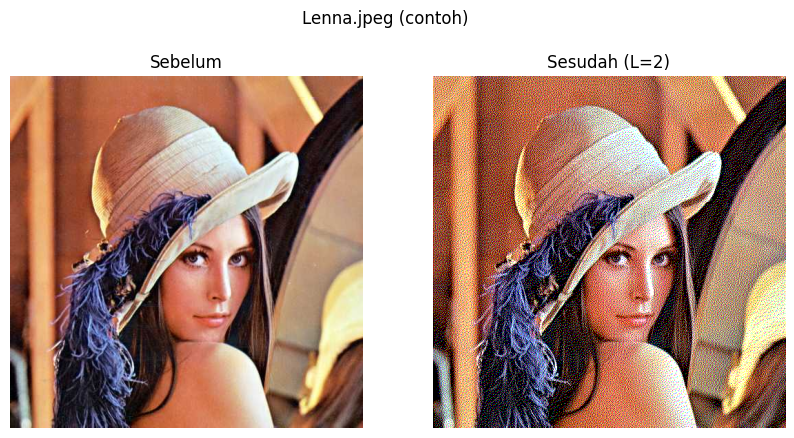

In [30]:
# Tahap 1: citra contoh (L=2 sesuai contoh pada modul)
_ = tampilkan_dithering(PATH + '/Lenna.jpeg', 'Lenna.jpeg (contoh)', L=2)

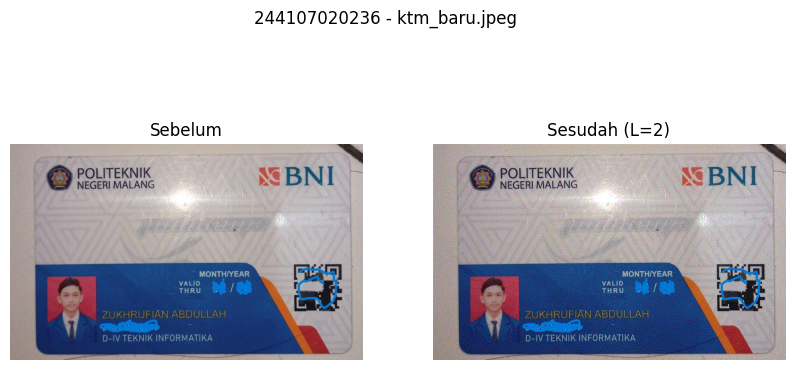

In [33]:
# Tahap 2: citra KTM milik sendiri
L_value = PARAM.get('L', 2)
_ = tampilkan_dithering(PATH + '/ktm_baru.jpeg', NIM + ' - ktm_baru.jpeg', L=L_value)

In [34]:
# Ubah citra menjadi grayscale
def bandingkan_dithering(path_gambar, judul, L):
    gray = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)

    # dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg(gray, L=L)

    # ekualisasi dulu, baru dithering
    gray_equalized = cv.equalizeHist(gray)
    dither_setelah_equalisasi = floyd_steinberg(gray_equalized, L=L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(dither_langsung, cmap='gray')
    axs[0].set_title('Dithering langsung'); axs[0].axis('off')
    axs[1].imshow(dither_setelah_equalisasi, cmap='gray')
    axs[1].set_title('Ekualisasi lalu dithering'); axs[1].axis('off')
    fig.suptitle(judul)
    plt.show()

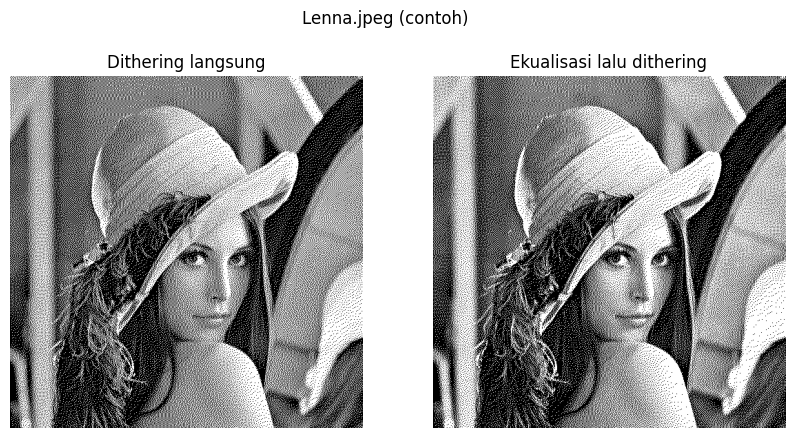

In [35]:
# Tahap 1: citra contoh
bandingkan_dithering(PATH + '/Lenna.jpeg', 'Lenna.jpeg (contoh)', L=2)

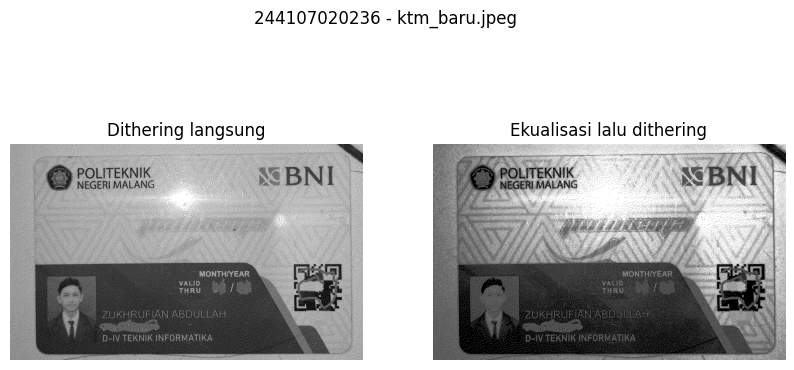

In [39]:
# Tahap 2: citra KTM milik sendiri
L_value = PARAM.get('L', 2)
bandingkan_dithering(PATH + '/ktm_baru.jpeg', NIM + ' - ktm_baru.jpeg', L=L_value)

* Urutan Terbaik: Melakukan Ekualisasi terlebih dahulu, baru kemudian Dithering menghasilkan teks yang jauh lebih terbaca.
* Penjelasan: Ekualisasi histogram memperlebar rentang kontras antara karakter teks (gelap) dan latar belakang kartu (terang). Ketika algoritma dithering Floyd-Steinberg diterapkan setelahnya, perbedaan kontras yang tajam ini dipertahankan dengan baik ke dalam bentuk biner (hitam-putih), sehingga bentuk huruf dan angka pada teks menjadi lebih tegas, utuh, dan mudah dibaca dibandingkan jika dilakukan dithering langsung tanpa ekualisasi.